# Causal AI Fairness Library Showcase

This notebook walks through a compact end-to-end workflow with the library:

- load a processed dataset
- define a Structural Fairness Model (SFM)
- fit a discrete Bayesian network
- compute observational and causal fairness effects
- inspect effect distributions
- build the same causal quantities symbolically

## 1. Imports and repository setup

The cell below makes the notebook robust whether it is launched from the repository root or from the notebooks directory.

In [67]:
from pathlib import Path
import sys

import pandas as pd
from pgmpy.estimators import BayesianEstimator

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

from src.effects import DE, IE, SE, TE, TV, effect_distribution, utility_weighted_effect
from src.graph import build_sfm
from src.model import fit_discrete_bayesian_model
from src.sym.dsl import Variable
from src.sym.effects import symbolic_NDE, symbolic_total_effect
from src.visualisation.graph import visualize_sfm

REPO_ROOT

PosixPath('/Users/alessiaberarducci/Desktop/WireGuard/causal-ai-fairness')

## 2. Load and prepare data

We reuse the processed Adult dataset and discretize `hours-per-week` into a small ordered set of categories so it can act as a mediator in the discrete Bayesian network.

In [68]:
data_path = REPO_ROOT / "data" / "processed" / "adult.csv"
df = pd.read_csv(data_path)

bins = [0, 20, 40, 60, 80, float("inf")]
labels = ["0-20", "21-40", "41-60", "61-80", "80+"]
df["hours-per-week"] = pd.cut(
    df["hours-per-week"], bins=bins, labels=labels, right=False
)

selected_columns = [
    "S2_gender",
    "relationship",
    "hours-per-week",
    "T_income",
]

df[selected_columns].head()

,S2_gender,relationship,hours-per-week,T_income
0,Male,Own-child,41-60,<=50K
1,Male,Husband,41-60,<=50K
2,Male,Husband,41-60,>50K
3,Male,Husband,41-60,>50K
4,Female,Own-child,21-40,<=50K


In [69]:
df[selected_columns].nunique().rename("cardinality")

S2_gender         2
relationship      6
hours-per-week    5
T_income          2
Name: cardinality, dtype: int64

## 3. Define the Structural Fairness Model

This graph encodes one sensitive attribute, one observed confounder, one mediator, and one outcome.

In [70]:
private_attr = "S2_gender"
outcome_attr = "T_income"
confounders = ["relationship"]
mediators = ["hours-per-week"]

sfm = build_sfm(
    sensitive_attr=private_attr,
    outcome_attr=outcome_attr,
    confounder_attrs=confounders,
    mediator_attrs=mediators,
)

sorted(sfm.edges())

[('S2_gender', 'T_income'),
 ('S2_gender', 'hours-per-week'),
 ('hours-per-week', 'T_income'),
 ('relationship', 'S2_gender'),
 ('relationship', 'T_income'),
 ('relationship', 'hours-per-week')]

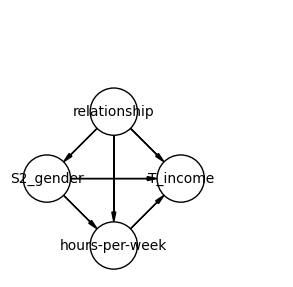

In [71]:
visualize_sfm(sfm)

## 4. Fit the Bayesian network

`fit_discrete_bayesian_model` keeps the SFM structure fixed and estimates the conditional distributions from the data.

In [72]:
df["S2_gender"] = df["S2_gender"].astype(str).astype("category")
df["relationship"] = df["relationship"].astype(str).astype("category")
df["T_income"] = df["T_income"].astype(str).astype("category")
df["hours-per-week"] = df["hours-per-week"].astype(str).astype("category")


In [73]:
bn = fit_discrete_bayesian_model(
    sfm=sfm,
    data=df[selected_columns],
    estimator_instance=(
        BayesianEstimator,
        {"prior_type": "dirichlet", "pseudo_counts": 1.0},
    ),
)

assert bn.check_model()
bn

2026-03-10 10:36:14.621 | DEBUG    | src.model:fit_discrete_bayesian_model:33 - Using estimator: <class 'pgmpy.estimators.BayesianEstimator.BayesianEstimator'> with parameters: {'prior_type': 'dirichlet', 'pseudo_counts': 1.0}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'S2_gender': 'C', 'relationship': 'C', 'hours-per-week': 'C', 'T_income': 'C'}


In [74]:
pd.Series(
    {node: bn.get_cpds(node).state_names[node] for node in bn.nodes}, name="states"
)

S2_gender                                            [Female, Male]
T_income                                              [<=50K, >50K]
relationship      [Husband, Not-in-family, Other-relative, Own-c...
hours-per-week                     [0-20, 21-40, 41-60, 61-80, 80+]
Name: states, dtype: object

## 5. Compute core fairness effects

We evaluate the probability of the `<=50K` outcome when comparing `Male` to `Female`.

In [75]:
target = (outcome_attr, "<=50K")
x0 = "Male"
x1 = "Female"

results = pd.Series(
    {
        "TV": TV(bn, target, private_attr, x0, x1),
        "TE": TE(bn, target, private_attr, x0, x1),
        "SE(Male)": SE(bn, target, private_attr, x0),
        "SE(Female)": SE(bn, target, private_attr, x1),
        "NDE": DE(bn, target, private_attr, x0, x1),
        "NIE": IE(bn, target, private_attr, x1, x0),
    },
    name="effect",
)

results.round(4)

2026-03-10 10:36:14.639 | DEBUG    | src.effects:total_variation:247 - Computing total variation for target=('T_income', '<=50K'), private_baseline=Male, private_mod=Female
2026-03-10 10:36:14.642 | DEBUG    | src.effects:spurious_effect:194 - Computing spurious effect for target=('T_income', '<=50K'), private_value=Male
2026-03-10 10:36:14.643 | DEBUG    | src.effects:spurious_effect:194 - Computing spurious effect for target=('T_income', '<=50K'), private_value=Female


TV            0.1939
TE            0.0225
SE(Male)     -0.0523
SE(Female)    0.1191
NDE           0.0473
NIE           0.0248
Name: effect, dtype: float64

## 6. Inspect full effect distributions

The library can return the full state-wise effect distribution for a target, not just a single state. That is useful when the target has multiple categories or when you want to define your own utility over outcomes.

In [76]:
target_states = bn.get_cpds(outcome_attr).state_names[outcome_attr]
te_distribution = effect_distribution(TE, bn, outcome_attr, private_attr, x0, x1)

pd.DataFrame({"state": target_states, "TE": te_distribution}).round(4)

,state,TE
0,<=50K,0.0225
1,>50K,-0.0225


In [77]:
utility_map = {"<=50K": 0.0, ">50K": 1.0}
utility_weighted_effect(TE, bn, outcome_attr, private_attr, x0, x1, utility_map)

-0.022491660596901913

## 7. Symbolic expressions for the same causal quantities

The symbolic DSL is useful when you want to manipulate fairness queries before choosing a numerical estimator.

In [78]:
X = Variable(private_attr, (x0, x1))
Y = Variable(outcome_attr, tuple(target_states))
W = Variable(mediators[0], tuple(labels))

symbolic_te = symbolic_total_effect(Y, "<=50K", X, x0, x1)
symbolic_nde = symbolic_NDE(Y, "<=50K", X, x0, x1, W)

symbolic_te, symbolic_nde

(P(Event(T_income_{S2_gender='Female'}='<=50K')) - P(Event(T_income_{S2_gender='Male'}='<=50K')),
 P(Event(T_income_{S2_gender='Female', hours-per-week=hours-per-week_{S2_gender='Male'}}='<=50K')) - P(Event(T_income_{S2_gender='Male'}='<=50K')))

## 8. Verify the decomposition identity

The decomposition tests in the suite verify the identity

$TV(x_0, x_1, y) = TE(x_0, x_1, y) + (SE(x_1, y) - SE(x_0, y))$.

Checking it directly in the notebook is a useful sanity test for a fitted model.

In [12]:
decomposition_check = pd.Series(
    {
        "TV": results["TV"],
        "TE + (SE(Female) - SE(Male))": results["TE"]
        + (results["SE(Female)"] - results["SE(Male)"]),
        "difference": results["TV"]
        - (results["TE"] + (results["SE(Female)"] - results["SE(Male)"])),
    },
)

decomposition_check.round(10)

TV                              0.1939
TE + (SE(Female) - SE(Male))    0.1939
difference                      0.0000
dtype: float64

The decomposition tests TE in the suite verify the identity

$TE(x_0, x_1, y) = NDE(x_0, x_1, y) - NIE(x_1,x_0,y)$.



In [80]:
decomposition_check_TE = pd.Series(
    {
        "TE": results["TE"],
        "NDE - NIE":  (results["NDE"] - results["NIE"]),
    },
)

decomposition_check_TE.round(10)

TE           0.022492
NDE - NIE    0.022492
dtype: float64

## 9. Compute matrix-valued effects for a multi-state sensitive attribute

For non-binary sensitive attributes, the library exposes categorical effect estimators that return an `EffectResult` object. Its matrix stores all pairwise comparisons between the chosen baseline states and modified states.

Here we rebuild the SFM with `relationship` as the sensitive attribute and keep `S2_gender` as a confounder.

In [13]:
from src.effects import (
    categorical_natural_direct_effect,
    categorical_natural_indirect_effect,
    categorical_total_effect,
    categorical_total_variation,
)

categorical_private_attr = "relationship"
categorical_target = (outcome_attr, "<=50K")
categorical_columns = [
    categorical_private_attr,
    "S2_gender",
    "hours-per-week",
    outcome_attr,
]

categorical_sfm = build_sfm(
    sensitive_attr=categorical_private_attr,
    outcome_attr=outcome_attr,
    confounder_attrs=["S2_gender"],
    mediator_attrs=["hours-per-week"],
)

categorical_bn = fit_discrete_bayesian_model(
    sfm=categorical_sfm,
    data=df[categorical_columns],
    estimator_instance=(
        BayesianEstimator,
        {"prior_type": "dirichlet", "pseudo_counts": 1.0},
    ),
)

relationship_states = categorical_bn.get_cpds(categorical_private_attr).state_names[
    categorical_private_attr
]

relationship_states

2026-03-10 10:36:14.675 | DEBUG    | src.model:fit_discrete_bayesian_model:33 - Using estimator: <class 'pgmpy.estimators.BayesianEstimator.BayesianEstimator'> with parameters: {'prior_type': 'dirichlet', 'pseudo_counts': 1.0}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'relationship': 'C', 'S2_gender': 'C', 'hours-per-week': 'C', 'T_income': 'C'}


['Husband',
 'Not-in-family',
 'Other-relative',
 'Own-child',
 'Unmarried',
 'Wife']

In [14]:
categorical_te = categorical_total_effect(
    categorical_bn,
    categorical_target,
    categorical_private_attr,
    relationship_states,
    relationship_states,
)
categorical_tv = categorical_total_variation(
    categorical_bn,
    categorical_target,
    categorical_private_attr,
    relationship_states,
    relationship_states,
)
categorical_nde = categorical_natural_direct_effect(
    categorical_bn,
    categorical_target,
    categorical_private_attr,
    relationship_states,
    relationship_states,
)
categorical_nie = categorical_natural_indirect_effect(
    categorical_bn,
    categorical_target,
    categorical_private_attr,
    relationship_states,
    relationship_states,
)

pd.DataFrame(
    categorical_te.matrix,
    index=relationship_states,
    columns=relationship_states,
).round(4)

2026-03-10 10:36:14.724 | DEBUG    | src.effects:total_variation:247 - Computing total variation for target=('T_income', '<=50K'), private_baseline=Husband, private_mod=Husband
2026-03-10 10:36:14.725 | DEBUG    | src.effects:total_variation:247 - Computing total variation for target=('T_income', '<=50K'), private_baseline=Husband, private_mod=Not-in-family
2026-03-10 10:36:14.726 | DEBUG    | src.effects:total_variation:247 - Computing total variation for target=('T_income', '<=50K'), private_baseline=Husband, private_mod=Other-relative
2026-03-10 10:36:14.726 | DEBUG    | src.effects:total_variation:247 - Computing total variation for target=('T_income', '<=50K'), private_baseline=Husband, private_mod=Own-child
2026-03-10 10:36:14.727 | DEBUG    | src.effects:total_variation:247 - Computing total variation for target=('T_income', '<=50K'), private_baseline=Husband, private_mod=Unmarried
2026-03-10 10:36:14.727 | DEBUG    | src.effects:total_variation:247 - Computing total variation f

,Husband,Not-in-family,Other-relative,Own-child,Unmarried,Wife
Husband,0.0000,0.3391,0.4072,0.4310,0.3492,-0.0147
Not-in-family,-0.3391,0.0000,0.0681,0.0919,0.0101,-0.3537
Other-relative,-0.4072,-0.0681,0.0000,0.0238,-0.0580,-0.4218
Own-child,-0.4310,-0.0919,-0.0238,0.0000,-0.0818,-0.4456
Unmarried,-0.3492,-0.0101,0.0580,0.0818,0.0000,-0.3639
Wife,0.0147,0.3537,0.4218,0.4456,0.3639,0.0000


In [83]:
categorical_summary = pd.DataFrame(
    {
        "mean": [
            categorical_te.mean_effect(),
            categorical_tv.mean_effect(),
            categorical_nde.mean_effect(),
            categorical_nie.mean_effect(),
        ],
        "variance": [
            categorical_te.variance_effect(),
            categorical_tv.variance_effect(),
            categorical_nde.variance_effect(),
            categorical_nie.variance_effect(),
        ],
        "largest |effect| pair": [
            categorical_te.max_disparity(),
            categorical_tv.max_disparity(),
            categorical_nde.max_disparity(),
            categorical_nie.max_disparity(),
        ],
    },
    index=["TE", "TV", "NDE", "NIE"],
)

categorical_summary

,mean,variance,largest |effect| pair
TE,-3.083953e-18,0.069247,"(-0.44561327858707156, Own-child, Wife)"
TV,3.083953e-18,0.073944,"(-0.4534155591184368, Own-child, Wife)"
NDE,-1.007204e-03,0.064756,"(-0.4632357601744025, Own-child, Wife)"
NIE,-1.007204e-03,0.000344,"(0.05060574265107842, Husband, Own-child)"


## 10. Summary

This notebook now covers the core workflow exposed by the package: structure definition, estimation, numerical fairness metrics, tested decomposition identities, multi-state categorical analyses, state-wise effect inspection, and symbolic causal expressions.